# 03 — Labels & Cube Assembly

**Week 3 goal:** Turn the 12 raw GeoTIFFs into a clean ML-ready datacube.

By the end of this notebook you will have:
1. Loaded all 12 TIFs and applied physical scale factors
2. Plotted sanity checks for each variable
3. Computed SPI-3, NDVI anomaly, and SM anomaly labels
4. Assembled and saved `dynamic.npy`, `static.npy`, `labels.npy`, `mask.npy`, `meta.json`
5. Verified the cube shape and label distributions

No GEE needed — this notebook is pure Python/NumPy, runs locally.

### What are the labels?

Our model predicts **three continuous values per pixel per month**:

| Label | What it measures | Range | Drought signal |
|-------|-----------------|-------|----------------|
| **SPI-3** | 3-month rainfall deficit vs historical gamma | −∞ to +∞, ~N(0,1) | < −1.0 |
| **NDVI anomaly** | Vegetation greenness vs seasonal norm | z-score | < −1.0 |
| **SM anomaly** | Soil moisture vs seasonal norm | z-score | < −1.0 |

All three are *continuous* (not categories). The model's job is to predict how far below normal each pixel is at the next time step.

In [ ]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# Run ONLY on Google Colab. Skip entirely if running locally.
try:
    from google.colab import drive
    import subprocess, sys
    drive.mount('/content/drive')
    _REPO = '/content/drive/MyDrive/botswana-drought-flood'
    _r = subprocess.run(['git', 'pull'], cwd=_REPO, capture_output=True, text=True)
    print(_r.stdout.strip() or 'Already up to date.')
    if _r.returncode != 0:
        print('git pull warning:', _r.stderr.strip())
    sys.path.insert(0, f'{_REPO}/src')
    DATA = f'{_REPO}/data'
    CUBE = f'{_REPO}/data/cube'
    print(f'CUBE → {CUBE}')
except ImportError:
    pass  # running locally — paths set below

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

from botswana_ds.cube import (
    build_dynamic, build_static, build_labels,
    DYNAMIC_CHANNELS, STATIC_CHANNELS, CH,
    H, W, T, SMAP_START,
)
from botswana_ds.labels import TRAIN_END

if 'DATA' not in globals():
    DATA = Path('..') / 'data'
if 'CUBE' not in globals():
    CUBE = Path('..') / 'data' / 'cube'
DATA = Path(DATA)
CUBE = Path(CUBE)
CUBE.mkdir(exist_ok=True)

print(f'Data dir : {DATA.resolve()}')
print(f'Cube dir : {CUBE.resolve()}')
print(f'T={T} months (Jan 2003 – Jun 2026)  H={H}  W={W}')
print(f'Training: t=0..{TRAIN_END-1} (Jan 2003 – Dec 2021)  Test: t={TRAIN_END}..{T-1} (Jan 2022 – Jun 2026)')

---
## Step 1 — Load raw data and apply scale factors

In [4]:
print('Loading dynamic channels ...')
dynamic, mask = build_dynamic(DATA)

print('Loading static channels ...')
static = build_static(DATA)

print(f'\ndynamic : {dynamic.shape}  ({dynamic.nbytes/1e6:.0f} MB)')
print(f'static  : {static.shape}')
print(f'mask    : {mask.shape}  valid pixels: {mask.sum():,} / {H*W:,} ({mask.mean()*100:.1f}%)')

# Quick value sanity check for each channel
print('\n=== Dynamic channel ranges (valid pixels, all months) ===')
print(f'{"Channel":14s}  {"Min":>10s}  {"Max":>10s}  {"Mean":>10s}')
print('-' * 52)
for c, (name, *_) in enumerate(DYNAMIC_CHANNELS):
    v = dynamic[:, c][mask[np.newaxis].repeat(T, axis=0)]
    v = v[~np.isnan(v)]
    if len(v) == 0:
        print(f'{name:14s}  (no valid data)')
    else:
        print(f'{name:14s}  {v.min():10.2f}  {v.max():10.2f}  {v.mean():10.2f}')

Loading dynamic channels ...
Loading static channels ...

dynamic : (252, 9, 182, 188)  (310 MB)
static  : (3, 182, 188)
mask    : (182, 188)  valid pixels: 20,486 / 34,216 (59.9%)

=== Dynamic channel ranges (valid pixels, all months) ===
Channel                Min         Max        Mean
----------------------------------------------------
rain_mm               0.00      484.34       33.66
t2m_c                 8.65       31.07       22.00
ndvi                 -0.20        0.87        0.33
evi                  -0.19        0.76        0.21
et_mm                 0.00      191.20       15.74
lst_c                14.13       60.99       33.85
sm_surf               0.01        0.39        0.07
dewpoint_c           -7.53       20.60        7.84
wind_ms               0.00        6.40        1.92


---
## Step 2 — Visual sanity checks

Before computing labels, confirm the raw data looks right. We'll plot January 2016 —
a major El Niño drought year — so we expect low rainfall and stressed vegetation.

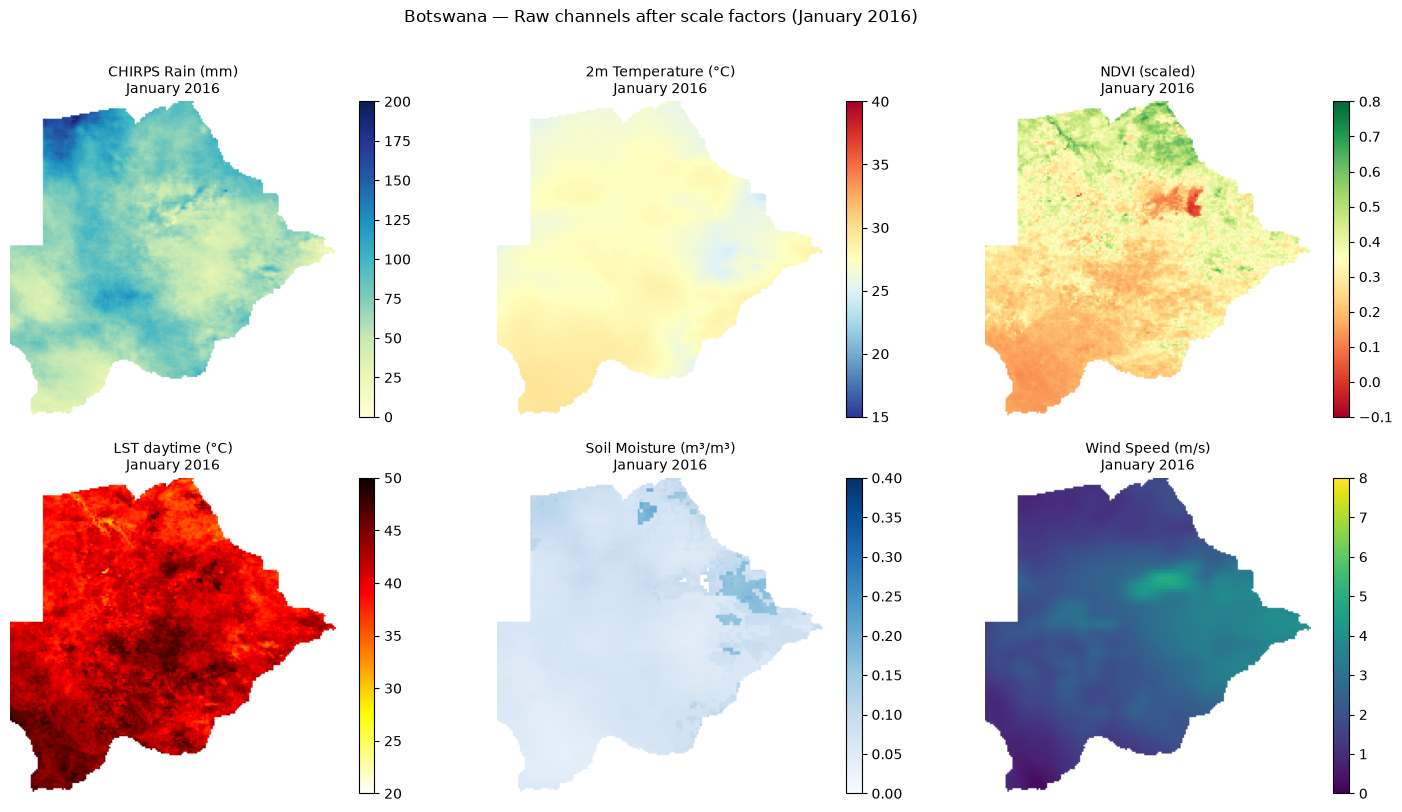


SMAP coverage check: t=156 >= SMAP_START=146 → True


In [5]:
# January 2016 = month index (2016-2003)*12 + 0 = 156
T_JAN2016 = (2016 - 2003) * 12 + 0   # index 156

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flat

plots = [
    (CH['rain_mm'],  'CHIRPS Rain (mm)',         'YlGnBu',  0,   200),
    (CH['t2m_c'],    '2m Temperature (°C)',       'RdYlBu_r', 15,  40),
    (CH['ndvi'],     'NDVI (scaled)',             'RdYlGn',  -0.1, 0.8),
    (CH['lst_c'],    'LST daytime (°C)',          'hot_r',   20,   50),
    (CH['sm_surf'],  'Soil Moisture (m³/m³)',     'Blues',    0,   0.4),
    (CH['wind_ms'],  'Wind Speed (m/s)',          'viridis',  0,    8),
]

for ax, (ch, title, cmap, vmin, vmax) in zip(axes, plots):
    data = dynamic[T_JAN2016, ch].copy()
    data[~mask] = np.nan
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, origin='upper')
    ax.set_title(f'{title}\nJanuary 2016', fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Botswana — Raw channels after scale factors (January 2016)', y=1.01)
plt.tight_layout()
plt.show()

# Soil moisture note: January 2016 is at t=156, SMAP starts at t=146 (March 2015).
# So sm_surf should have valid data here.
print(f'\nSMAP coverage check: t={T_JAN2016} >= SMAP_START={SMAP_START} → {T_JAN2016 >= SMAP_START}')

---
## Step 3 — Compute labels

This is the core of Week 3. Three labels, all computed on **training data only**.

**SPI-3** takes ~2–5 minutes (gamma fit per pixel × 12 calendar months).  
**NDVI and SM anomaly** are fast (vectorized z-score).

In [6]:
labels = build_labels(dynamic, mask, train_end=TRAIN_END)
print(f'\nlabels shape: {labels.shape}  ({labels.nbytes/1e6:.0f} MB)')
print('Channels: [0] SPI-3   [1] NDVI anomaly   [2] SM anomaly')

  Computing SPI-3 (gamma fit per pixel per calendar month) ...


/Users/andrewsimons/botswana-drought-flood/src/botswana_ds/labels.py:78: RuntimeWarning: Mean of empty slice
  mu       = np.nanmean(x_pos, axis=0)   # (H, W)
/Users/andrewsimons/botswana-drought-flood/src/botswana_ds/labels.py:79: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var      = np.nanvar(x_pos, axis=0)    # (H, W)
/Users/andrewsimons/botswana-drought-flood/src/botswana_ds/labels.py:81: RuntimeWarning: divide by zero encountered in divide
  alpha = np.where(valid_fit, mu ** 2 / var, np.nan)   # shape


  Computing NDVI anomaly ...
  Computing SM anomaly ...


/Users/andrewsimons/botswana-drought-flood/src/botswana_ds/labels.py:139: RuntimeWarning: Mean of empty slice
  mu  = np.nanmean(x_train, axis=0)             # (H, W)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



labels shape: (252, 3, 182, 188)  (103 MB)
Channels: [0] SPI-3   [1] NDVI anomaly   [2] SM anomaly


---
## Step 4 — Check label distributions

**Expected:**
- SPI-3 should look roughly normal (mean ≈ 0, std ≈ 1) over the training period.
- NDVI and SM anomalies should also be roughly N(0,1) by construction.
- January 2016 (El Niño drought) should show strongly negative SPI-3 and NDVI anomaly.

SPI-3            mean=+0.175  std=0.945  NaN%=40.6
NDVI anomaly     mean=+0.000  std=1.000  NaN%=40.1
SM anomaly       mean=+0.000  std=1.000  NaN%=74.9


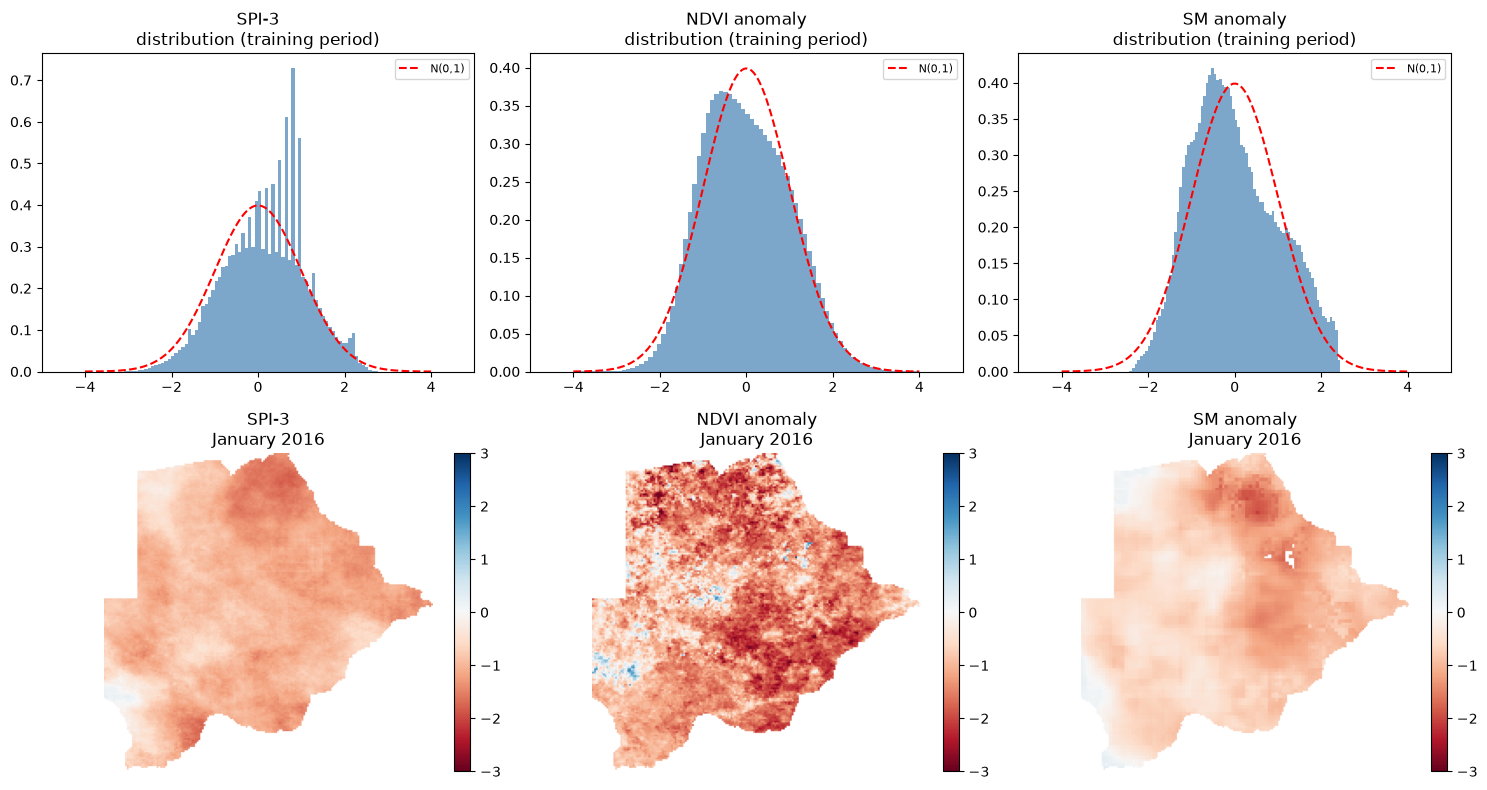

In [7]:
label_names = ['SPI-3', 'NDVI anomaly', 'SM anomaly']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, name in enumerate(label_names):
    lbl = labels[:, i]  # (T, H, W)
    valid = lbl[~np.isnan(lbl)]
    train_valid = labels[:TRAIN_END, i][~np.isnan(labels[:TRAIN_END, i])]
    
    # Histogram over full training period
    ax = axes[0, i]
    ax.hist(train_valid, bins=80, color='steelblue', alpha=0.7, density=True)
    x = np.linspace(-4, 4, 200)
    from scipy import stats
    ax.plot(x, stats.norm.pdf(x), 'r--', lw=1.5, label='N(0,1)')
    ax.set_title(f'{name}\ndistribution (training period)')
    ax.set_xlim(-5, 5)
    ax.legend(fontsize=8)
    print(f'{name:15s}  mean={train_valid.mean():+.3f}  std={train_valid.std():.3f}  '
          f'NaN%={np.isnan(lbl).mean()*100:.1f}')

    # Map for January 2016
    ax = axes[1, i]
    data = labels[T_JAN2016, i].copy()
    data[~mask] = np.nan
    im = ax.imshow(data, cmap='RdBu', vmin=-3, vmax=3, origin='upper')
    ax.set_title(f'{name}\nJanuary 2016')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

---
## Step 5 — Event-level validation

Cross-check against EM-DAT: Botswana had major droughts in **2015–16** and **2023–24**.
Plot the spatially-averaged SPI-3 over the full time series — the 2015-16 El Niño drought
should show a clear dip.

In [ ]:
# Botswana-average SPI-3 over time
spi_series = np.nanmean(labels[:, 0, :, :].reshape(T, -1), axis=1)  # (T,)

# Month axis
import pandas as pd
months = pd.date_range('2003-01', periods=T, freq='MS')

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(months, spi_series, 0,
                where=spi_series < 0, color='#d73027', alpha=0.6, label='Below normal')
ax.fill_between(months, spi_series, 0,
                where=spi_series > 0, color='#4575b4', alpha=0.5, label='Above normal')
ax.plot(months, spi_series, 'k-', lw=0.8)
ax.axhline(-1, color='red', lw=1, ls='--', label='Drought threshold (SPI = −1)')
ax.axvline(pd.Timestamp('2015-10'), color='orange', lw=1.5, ls=':', label='El Niño peak')
ax.axvspan(pd.Timestamp('2022-01'), pd.Timestamp('2026-07'), alpha=0.1, color='gray', label='Test period')
ax.set_ylabel('Mean SPI-3 (Botswana-wide)')
ax.set_title('Botswana-average SPI-3  (2003–2026)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

# Identify the 5 driest months by SPI
driest_idx = np.argsort(spi_series)[:5]
print('5 driest months (lowest mean SPI-3):')
for idx in driest_idx:
    print(f'  {months[idx].strftime("%Y-%m")}  SPI = {spi_series[idx]:.3f}')

---
## Step 6 — Save cube

In [ ]:
import json
from botswana_ds.grid import make_grid
from botswana_ds.cube import DYNAMIC_CHANNELS, STATIC_CHANNELS, SMAP_START, SMAP_N

print('Saving cube ...')
np.save(CUBE / 'dynamic.npy', dynamic)
np.save(CUBE / 'static.npy',  static)
np.save(CUBE / 'labels.npy',  labels)
np.save(CUBE / 'mask.npy',    mask)

g = make_grid()
meta = {
    'grid': {'min_lon': g.min_lon, 'min_lat': g.min_lat,
              'max_lon': g.max_lon, 'max_lat': g.max_lat,
              'res': g.res, 'H': H, 'W': W},
    'time': {'start': '2003-01', 'end': '2026-06', 'T': T},
    'dynamic_channels': [ch[0] for ch in DYNAMIC_CHANNELS],
    'static_channels':  [ch[0] for ch in STATIC_CHANNELS],
    'label_channels':   ['spi3', 'ndvi_anom', 'sm_anom'],
    'splits': {
        'train_end_idx':   TRAIN_END,
        'train_end_date':  '2021-12',
        'test_start_idx':  TRAIN_END,
        'test_start_date': '2022-01',
    },
    'smap': {'start_idx': SMAP_START, 'start_date': '2015-01', 'n_bands': SMAP_N},
}
with open(CUBE / 'meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
for p in sorted(CUBE.iterdir()):
    size = p.stat().st_size / 1e6
    print(f'  {p.name:20s}  {size:.1f} MB')

---
## Week 3 success criteria

| Check | Expected |
|-------|----------|
| `dynamic.shape` | `(282, 9, 182, 188)` |
| `static.shape`  | `(3, 182, 188)` |
| `labels.shape`  | `(282, 3, 182, 188)` |
| `mask.sum()`    | ~20,000–21,000 valid pixels |
| Rain range      | 0–~500 mm/month (no negatives) |
| Temperature range | 15–45°C plausible for Botswana |
| NDVI range      | −0.1 to ~0.8 (after ×0.0001) |
| SPI-3 distribution | ~N(0,1), mean near 0 |
| 2015–16 drought visible | SPI dips below −1 in 2015–16 |
| Files in `data/cube/` | 4 `.npy` + `meta.json` |

**All checks pass? You're ready for Week 4** — PyTorch Dataset + DataLoader.

In Week 4 we'll build `BotswanaDroughtDataset` which:
- Loads from `data/cube/`
- Returns `(dynamic_window, static, label_next_month)` per sample
- Applies per-pixel z-score normalization (fitted on training split only)
- Handles the train/test split correctly